In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
trades = pd.read_csv("/Users/asmitabaul/Downloads/historical_data.csv")
sentiment = pd.read_csv("/Users/asmitabaul/Downloads/fear_greed_index.csv")

# Quick overview
print(trades.shape)
print(sentiment.shape)

print(trades.columns)
print(sentiment.columns)

(211224, 16)
(2644, 4)
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
# Convert timestamps
trades['date'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Reduce to daily level
trades['date'] = trades['date'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Drop null dates
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

# Remove duplicates
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

In [7]:
# Clean PnL
trades['Closed PnL'] = pd.to_numeric(trades['Closed PnL'], errors='coerce')

# Profit flag
trades['is_profit'] = (trades['Closed PnL'] > 0).astype(int)

# Trade counter
trades['trade_count'] = 1

# Trade direction
trades['is_long'] = (trades['Side'] == 'BUY').astype(int)

In [8]:
daily_trades = trades.groupby('date').agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'trade_count': 'sum',
    'is_profit': 'mean',
    'is_long': 'mean'
}).reset_index()

daily_trades.rename(columns={
    'Closed PnL': 'daily_pnl',
    'Size USD': 'avg_trade_size',
    'trade_count': 'trades_per_day',
    'is_profit': 'win_rate',
    'is_long': 'long_ratio'
}, inplace=True)

print(daily_trades.head())

         date    daily_pnl  avg_trade_size  trades_per_day  win_rate  \
0  2023-01-05     0.000000      159.000000               3  0.000000   
1  2023-05-12     0.000000     5556.203333               9  0.000000   
2  2024-01-01  -129.531460    14679.973889              18  0.055556   
3  2024-01-02     0.000000      334.696667               6  0.000000   
4  2024-01-03  8244.241409     3452.370073             137  0.934307   

   long_ratio  
0    1.000000  
1    0.777778  
2    0.555556  
3    1.000000  
4    0.270073  


In [9]:
data = pd.merge(daily_trades, sentiment, on='date', how='inner')

# Use given classification
data.rename(columns={'classification': 'sentiment_label'}, inplace=True)

print(data.head())

         date    daily_pnl  avg_trade_size  trades_per_day  win_rate  \
0  2023-01-05     0.000000      159.000000               3  0.000000   
1  2023-05-12     0.000000     5556.203333               9  0.000000   
2  2024-01-01  -129.531460    14679.973889              18  0.055556   
3  2024-01-02     0.000000      334.696667               6  0.000000   
4  2024-01-03  8244.241409     3452.370073             137  0.934307   

   long_ratio   timestamp  value sentiment_label  
0    1.000000  1672896600     29            Fear  
1    0.777778  1683869400     49         Neutral  
2    0.555556  1704087000     65           Greed  
3    1.000000  1704173400     71           Greed  
4    0.270073  1704259800     70           Greed  


In [10]:
performance = data.groupby('sentiment_label').agg({
    'daily_pnl': ['mean', 'std'],
    'win_rate': 'mean'
}).reset_index()

performance.columns = ['sentiment', 'avg_pnl', 'pnl_volatility', 'avg_win_rate']
print(performance)

       sentiment       avg_pnl  pnl_volatility  avg_win_rate
0   Extreme Fear    733.322758     2798.334049      0.307500
1  Extreme Greed  26904.504083   112472.212014      0.319642
2           Fear  48087.177910   132965.887414      0.348071
3          Greed  10886.295226    39493.424342      0.362415
4        Neutral   4666.046374    10806.052601      0.286719


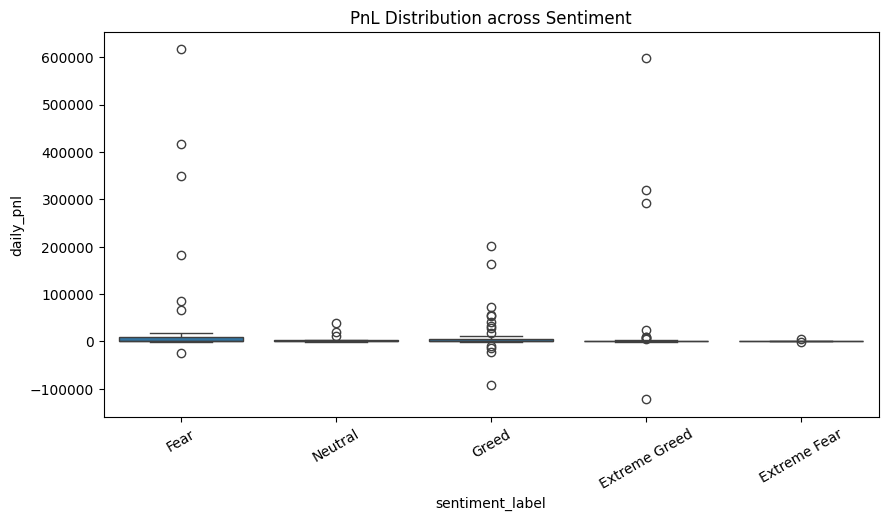

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x='sentiment_label', y='daily_pnl', data=data)
plt.title("PnL Distribution across Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight: PnL Distribution across Sentiment

- Fear shows the highest average profitability (~48k), but also very high variability.
- Extreme Greed has significantly lower average PnL (~2.7k), despite strong positive sentiment.
- Both Fear and Extreme Greed show large outliers, indicating unstable returns.
- Neutral markets show relatively lower returns and lower variability.

*Interpretation:*
- Profits are highest during Fear but come with high uncertainty.  
- Extreme Greed leads to poor performance, likely due to overconfidence.

*Conclusion:* Emotional extremes increase volatility, but only fear creates strong profit opportunities.

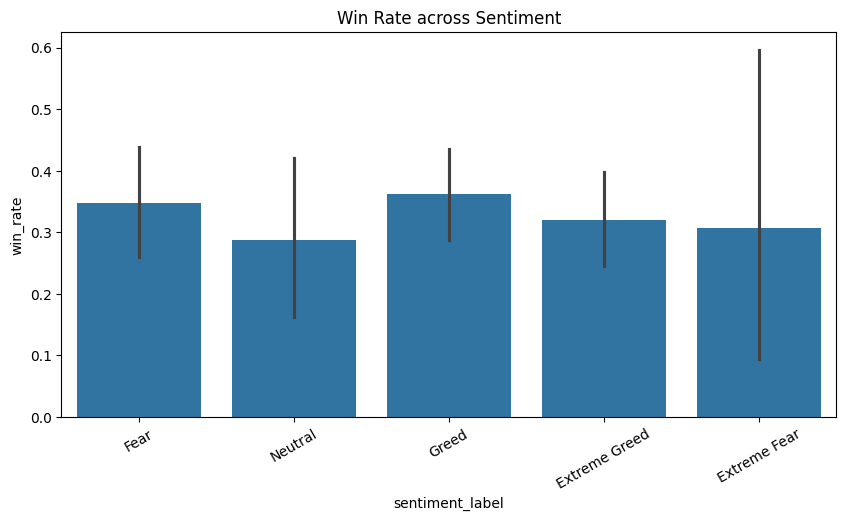

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x='sentiment_label', y='win_rate', data=data)
plt.title("Win Rate across Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight: Win Rate across Sentiment

- Win rate peaks during Greed **(~36%)** and is lowest during Neutral **(~28%)**.
- Fear and Extreme Fear show moderate win rates (~30–34%).
- Differences in win rate are relatively small compared to PnL differences.

*Interpretation:* 
- Sentiment has a limited impact on success rate, suggesting that profitability differences come more from trade size or frequency.

*Conclusion:* Winning frequency is relatively stable across sentiments; profits depend more on trade behavior.

In [13]:
behavior = data.groupby('sentiment_label').agg({
    'avg_trade_size': 'mean',
    'trades_per_day': 'mean',
    'long_ratio': 'mean'
}).reset_index()

print(behavior)

  sentiment_label  avg_trade_size  trades_per_day  long_ratio
0    Extreme Fear     2191.149008      387.666667    0.526547
1   Extreme Greed     7954.335976      130.720930    0.513542
2            Fear     6014.623918      374.837838    0.514903
3           Greed     6352.086535      201.642857    0.511233
4         Neutral     7191.752725      172.250000    0.443245


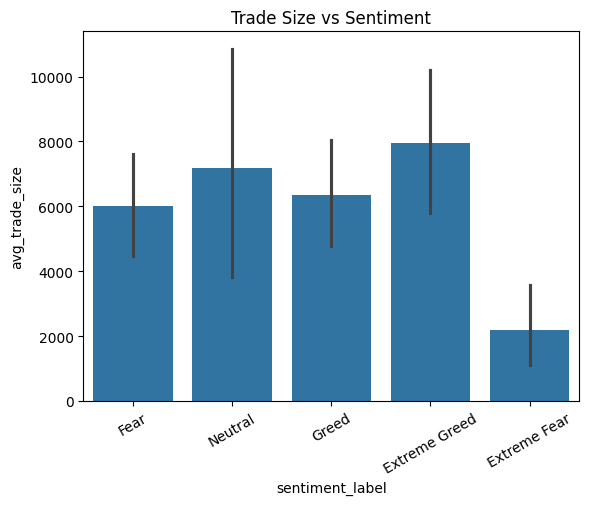

In [14]:
sns.barplot(x='sentiment_label', y='avg_trade_size', data=data)
plt.xticks(rotation=30)
plt.title("Trade Size vs Sentiment")
plt.show()

### Insight: Trade Size vs Sentiment

- Trade sizes are highest during Extreme Greed **(~7954)** and Neutral **(~7191)**.
- Fear and Greed show moderate trade sizes (~6000–6300).
- Extreme Fear has the smallest trade sizes (~2191).

*Interpretation:*
- Traders take larger risks during confident market conditions and reduce exposure during fear.

*Conclusion:*
Greed increases risk-taking, while fear leads to cautious trading behavior.

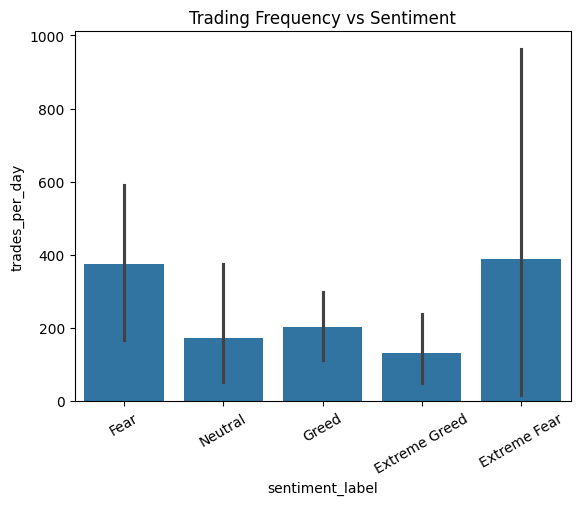

In [15]:
sns.barplot(x='sentiment_label', y='trades_per_day', data=data)
plt.xticks(rotation=30)
plt.title("Trading Frequency vs Sentiment")
plt.show()

### Insight: Trading Frequency vs Sentiment

- Trading activity is highest during Extreme Fear **(~388 trades/day)** and Fear **(~375)**.
- Activity drops significantly during Extreme Greed (~130 trades/day).
- Neutral and Greed show moderate activity (~170–200 trades/day).

*Interpretation:*
- Fear-driven markets trigger more trading, possibly due to panic or opportunity-seeking behavior.

*Conclusion:*
Fear increases activity, while greed reduces urgency to trade.

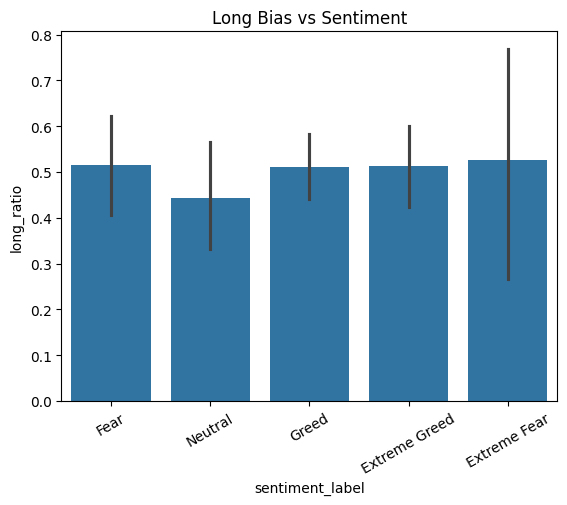

In [16]:
sns.barplot(x='sentiment_label', y='long_ratio', data=data)
plt.xticks(rotation=30)
plt.title("Long Bias vs Sentiment")
plt.show()

### Insight: Long Bias vs Sentiment

- Long ratio remains relatively stable (~0.51–0.52) across most sentiments.
- Neutral markets show a slightly lower long bias (~0.44).
- Extreme Fear shows high variability in position direction.

*Interpretation:*
- Traders generally maintain a balanced bias regardless of sentiment, with slight uncertainty during neutral markets.

*Conclusion:* Market sentiment does not strongly influence directional bias.

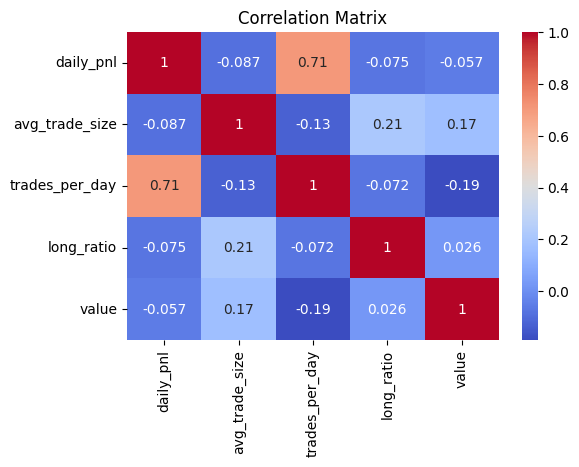

In [17]:
corr = data[['daily_pnl', 'avg_trade_size', 'trades_per_day', 'long_ratio', 'value']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Insight: Correlation Analysis

- Daily PnL strongly correlates with trading frequency (~0.71).
- Trade size has weak correlation with PnL (~ -0.08).
- Sentiment has very weak correlation with profitability (~ -0.057).

*Interpretation:*
- Profitability depends more on how often traders trade rather than sentiment itself.

*Conclusion:* Behavioral factors drive performance more than sentiment alone.

In [18]:
# Create threshold (median is robust)
activity_threshold = data['trades_per_day'].median()

data['activity_segment'] = np.where(
    data['trades_per_day'] >= activity_threshold,
    'High Activity',
    'Low Activity'
)

In [19]:
activity_perf = data.groupby('activity_segment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'trades_per_day': 'mean'
}).reset_index()

print(activity_perf)

  activity_segment     daily_pnl  win_rate  trades_per_day
0    High Activity  44606.428001  0.419896      431.925000
1     Low Activity    721.720888  0.253325       16.794872


In [20]:
size_threshold = data['avg_trade_size'].median()

data['size_segment'] = np.where(
    data['avg_trade_size'] >= size_threshold,
    'Large Traders',
    'Small Traders'
)

In [21]:
size_perf = data.groupby('size_segment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

print(size_perf)

    size_segment     daily_pnl  win_rate  avg_trade_size
0  Large Traders  18541.183406  0.321781    11231.099568
1  Small Traders  27342.468105  0.353548     2041.170249


In [22]:
# Rolling volatility (risk proxy)
data['pnl_volatility'] = data['daily_pnl'].rolling(7).std()

vol_threshold = data['pnl_volatility'].median()

data['consistency_segment'] = np.where(
    data['pnl_volatility'] <= vol_threshold,
    'Consistent',
    'Volatile'
)

In [23]:
consistency_perf = data.groupby('consistency_segment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'pnl_volatility': 'mean'
}).reset_index()

print(consistency_perf)

  consistency_segment    daily_pnl  win_rate  pnl_volatility
0          Consistent   2597.16299  0.287074     4895.698718
1            Volatile  41797.85466  0.384553    86242.382466


In [24]:
activity_sentiment = data.groupby(['sentiment_label', 'activity_segment']).agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
}).reset_index()

print(activity_sentiment)

  sentiment_label activity_segment     daily_pnl  win_rate
0    Extreme Fear    High Activity   1831.262759  0.284568
1    Extreme Fear     Low Activity    184.352759  0.318966
2   Extreme Greed    High Activity  75216.673687  0.399242
3   Extreme Greed     Low Activity   1022.984652  0.276999
4            Fear    High Activity  84285.525840  0.442270
5            Fear     Low Activity    576.846251  0.224434
6           Greed    High Activity  18585.954836  0.439524
7           Greed     Low Activity    620.082412  0.259603
8         Neutral    High Activity   7185.501190  0.368144
9         Neutral     Low Activity    466.955014  0.151010


In [25]:
size_sentiment = data.groupby(['sentiment_label', 'size_segment']).agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
}).reset_index()

print(size_sentiment)

  sentiment_label   size_segment     daily_pnl  win_rate
0    Extreme Fear  Large Traders  -2365.961276  0.297483
1    Extreme Fear  Small Traders   1353.179565  0.309503
2   Extreme Greed  Large Traders  -3838.129989  0.314889
3   Extreme Greed  Small Traders  62258.533267  0.325108
4            Fear  Large Traders  73869.424765  0.359831
5            Fear  Small Traders  17755.122785  0.334235
6           Greed  Large Traders   2433.648064  0.314098
7           Greed  Small Traders  18756.001204  0.407400
8         Neutral  Large Traders   1537.430885  0.275436
9         Neutral  Small Traders   7794.661863  0.298002


In [26]:
consistency_sentiment = data.groupby(['sentiment_label', 'consistency_segment']).agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
}).reset_index()

print(consistency_sentiment)

  sentiment_label consistency_segment      daily_pnl  win_rate
0    Extreme Fear          Consistent     202.757398  0.333333
1    Extreme Fear            Volatile    1263.888119  0.281666
2   Extreme Greed          Consistent    2386.136468  0.295261
3   Extreme Greed            Volatile   64403.183965  0.356931
4            Fear          Consistent    3491.222605  0.333087
5            Fear            Volatile  100553.007680  0.365698
6           Greed          Consistent    2729.458761  0.235566
7           Greed            Volatile   15074.940978  0.427553
8         Neutral          Consistent    1631.549792  0.250420
9         Neutral            Volatile    7700.542956  0.323018


## Insight: Trader Segmentation

- High-activity traders significantly outperform low-activity traders in both PnL **(~44k vs ~722)** and win rate **(~42% vs ~25%)**.
- Small traders outperform large traders in both PnL and win rate.
- Volatile traders generate higher returns (~41k) but with much higher risk.

*Interpretation:*
Higher returns are linked to higher activity and higher risk.

*Conclusion:*
There is a clear trade-off between risk and stability in trading performance.

### Strategy Recommendations

1. Reduce Exposure During Extreme Greed
- Large traders show negative or poor performance in Extreme Greed.
- Limit position size and avoid overconfidence-driven trades.

Insight:
Extreme optimism leads to poor risk-adjusted outcomes.

---

2. Leverage High Activity During Fear
- High-activity traders perform best during Fear conditions (~84k PnL).

Strategy:
Increase participation during fear-driven markets, but manage volatility.

---

3. Favor Small Traders in Volatile Markets
- Small traders outperform large traders, especially in Extreme Greed.

Strategy:
Use smaller, controlled positions to adapt better to market swings.

---

4. Balance Risk vs Stability
- Volatile traders achieve higher returns but at much higher risk.
- Consistent traders provide stability but lower returns.

Strategy:
Combine both approaches — allocate more capital to consistent strategies and selectively use high-risk strategies.

---

Overall Strategy Insight

Market sentiment does not directly determine profitability but strongly influences trader behavior.  
By controlling risk during greed and leveraging opportunities during fear, traders can improve performance.

Final Takeaway:
**Disciplined risk management and adaptive behavior outperform emotion-driven trading.**

In [27]:
data = data.sort_values('date')

# Next day PnL
data['next_day_pnl'] = data['daily_pnl'].shift(-1)

# Target: profitable or not
data['target'] = (data['next_day_pnl'] > 0).astype(int)

# Drop last row (no target)
data = data.dropna()

In [28]:
features = [
    'value',             
    'avg_trade_size',
    'trades_per_day',
    'long_ratio'
]

X = data[features]
y = data['target']

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6774193548387096
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.68      1.00      0.81        21

    accuracy                           0.68        31
   macro avg       0.34      0.50      0.40        31
weighted avg       0.46      0.68      0.55        31



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [31]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[ 0 10]
 [ 0 21]]
